# Step 6 - Develop Early Indicators of Liquidity Crossover

Build candidate signals from information available by each date and label whether the first volume crossover occurs within the next 1, 3, or 5 business days. This notebook explores candidate indicators; model fitting and roll-level out-of-sample evaluation belong in Step 7.

Run `05_define_crossover.ipynb` first. The panel and event table are treated as valid inputs in this notebook.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

panel = pd.read_parquet('../data/processed/zn_roll_panel.parquet')
events = pd.read_parquet('../data/processed/zn_crossover_events.parquet')
panel['date'] = pd.to_datetime(panel['date'])
events['volume_crossover_date'] = pd.to_datetime(events['volume_crossover_date'])
panel = panel.sort_values(['roll_id', 'bdays_to_fnd']).copy()

required_panel = {'roll_id', 'date', 'bdays_to_fnd', 'next_volume_share',
                  'next_oi_share', 'spread_volume', 'total_volume'}
missing = required_panel - set(panel.columns)
if missing:
    raise ValueError(f'Panel missing columns: {sorted(missing)}')
required_events = {'roll_id', 'volume_crossover_observed',
                   'volume_crossover_bdays_to_fnd'}
missing = required_events - set(events.columns)
if missing:
    raise ValueError(f'Event table missing columns: {sorted(missing)}')

print(f'{panel.roll_id.nunique()} rolls | {len(panel):,} panel rows')
print(f"Volume crossover observed for {events.volume_crossover_observed.sum()} rolls")

27 rolls | 837 panel rows
Volume crossover observed for 27 rolls


## 1. Candidate indicators

Current-day shares and spread activity are available after that trading day closes. Share changes compare today's value with 3 or 5 panel business days earlier. These features use no future rows.

In [9]:
feature_panel = panel.merge(
    events[['roll_id', 'volume_crossover_observed', 'volume_crossover_bdays_to_fnd']],
    on='roll_id', how='left', validate='many_to_one')
feature_panel = feature_panel.sort_values(['roll_id', 'bdays_to_fnd']).copy()

for column, lags in [('next_volume_share', [3, 5]), ('next_oi_share', [3])]:
    for lag in lags:
        feature_panel[f'{column}_change_{lag}d'] = (
            feature_panel.groupby('roll_id')[column].diff(lag))

feature_panel['log_spread_volume'] = np.log1p(feature_panel['spread_volume'].clip(lower=0))
feature_columns = [
    'bdays_to_fnd',
    'next_volume_share',
    'next_volume_share_change_3d',
    'next_volume_share_change_5d',
    'next_oi_share',
    'next_oi_share_change_3d',
    'log_spread_volume',
]
display(feature_panel[['roll_id', 'date'] + feature_columns].head(10))

,roll_id,date,bdays_to_fnd,next_volume_share,next_volume_share_change_3d,next_volume_share_change_5d,next_oi_share,next_oi_share_change_3d,log_spread_volume
0,ZNH0->ZNM0,2020-01-30,-25,0.000250,NaN,NaN,0.025428,NaN,10.296914
1,ZNH0->ZNM0,2020-01-31,-24,0.000436,NaN,NaN,0.030530,NaN,10.235521
2,ZNH0->ZNM0,2020-02-02,-23,0.001822,NaN,NaN,0.035261,NaN,4.624973
3,ZNH0->ZNM0,2020-02-03,-22,0.000303,0.000053,NaN,0.035345,0.009917,9.495970
4,ZNH0->ZNM0,2020-02-04,-21,0.001307,0.000871,NaN,0.037490,0.006960,9.249946
5,ZNH0->ZNM0,2020-02-05,-20,0.001520,-0.000303,0.001270,0.039337,0.004077,9.600760
6,ZNH0->ZNM0,2020-02-06,-19,0.000939,0.000636,0.000503,0.041924,0.006579,9.709599
7,ZNH0->ZNM0,2020-02-07,-18,0.001633,0.000327,-0.000189,0.044894,0.007404,9.605620
8,ZNH0->ZNM0,2020-02-09,-17,0.005374,0.003854,0.005071,0.044865,0.005528,6.025866
9,ZNH0->ZNM0,2020-02-10,-16,0.002976,0.002037,0.001669,0.044832,0.002908,9.770470


## 2. Create forward crossover labels

A positive label means the first volume crossover falls 1, 3, or 5 business days after the feature date. The crossover date itself and later dates are excluded because the event has already happened. Rows near the end of a roll window are excluded when the full prediction horizon is not observed.

In [10]:
HORIZONS = [1, 3, 5]
for horizon in HORIZONS:
    label_name = f'crossover_within_{horizon}d'
    labels = pd.Series(np.nan, index=feature_panel.index, dtype='float64')
    for roll_id, idx in feature_panel.groupby('roll_id', sort=False).groups.items():
        grp = feature_panel.loc[idx]
        last_bday = grp['bdays_to_fnd'].max()
        event_rows = grp['volume_crossover_bdays_to_fnd'].dropna()
        event_bday = event_rows.iloc[0] if not event_rows.empty else np.nan
        full_horizon = grp['bdays_to_fnd'] + horizon <= last_bday
        before_event = grp['bdays_to_fnd'] < event_bday if pd.notna(event_bday) else pd.Series(True, index=grp.index)
        eligible = full_horizon & before_event
        labels.loc[idx[eligible.to_numpy()]] = 0.0
        if pd.notna(event_bday):
            delta = event_bday - grp['bdays_to_fnd']
            positive = eligible & delta.between(1, horizon)
            labels.loc[idx[positive.to_numpy()]] = 1.0
    feature_panel[label_name] = labels

label_summary = pd.DataFrame([
    {'horizon_business_days': h,
     'eligible_rows': feature_panel[f'crossover_within_{h}d'].notna().sum(),
     'positive_rows': feature_panel[f'crossover_within_{h}d'].sum(),
     'positive_rate': feature_panel[f'crossover_within_{h}d'].mean()}
    for h in HORIZONS
])
display(label_summary)

,horizon_business_days,eligible_rows,positive_rows,positive_rate
0,1,620,27.0,0.043548
1,3,620,81.0,0.130645
2,5,620,135.0,0.217742


## 3. Inspect signals by lead time

For rolls with an observed event, compare feature values on days before crossover. The count column shows how many roll-days contribute at each lead. This is descriptive; repeated days within one roll are related observations and should not be treated as independent evidence.

,roll_days,rolls,volume_share_median,volume_share_change_3d_median,oi_share_median,oi_share_change_3d_median,log_spread_volume_median
days_until_crossover,,,,,,,
1,27,27,0.393623,0.271571,0.649319,0.426790,14.243829
2,27,27,0.247594,0.169940,0.471114,0.346127,14.426784
3,27,27,0.169186,0.117962,0.335818,0.276284,14.219404
4,27,27,0.128414,0.105106,0.212147,0.159137,14.141084
5,27,27,0.077633,0.069316,0.116159,0.074132,13.477498
6,27,27,0.050226,0.034737,0.061458,0.030050,12.874758
7,27,27,0.025518,0.018569,0.040618,0.013377,11.677524
8,27,27,0.015395,0.009287,0.032770,0.011439,11.125482
9,27,27,0.008399,0.005327,0.029901,0.013003,10.092247


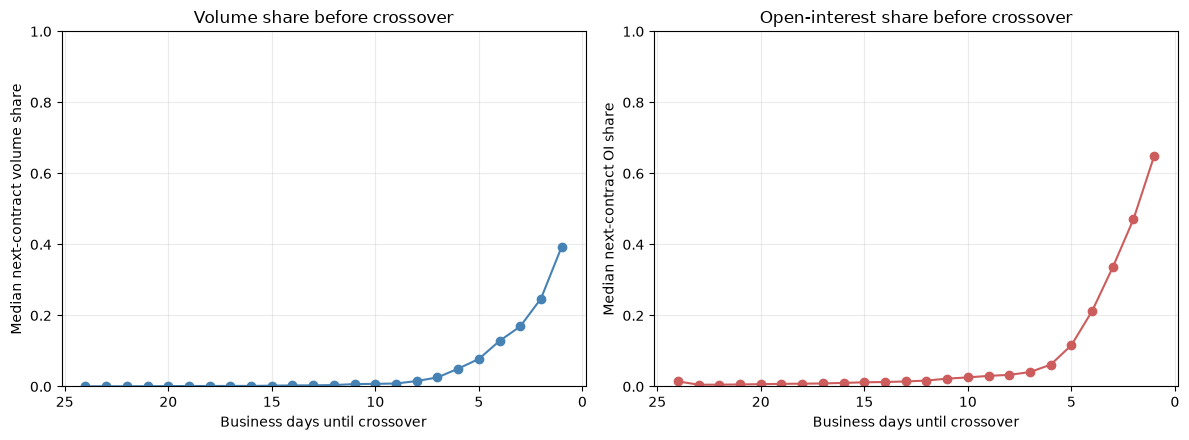

In [11]:
event_lookup = (events.loc[events['volume_crossover_observed']]
    .set_index('roll_id')['volume_crossover_bdays_to_fnd'])
feature_panel['days_until_crossover'] = feature_panel.apply(
    lambda r: event_lookup.get(r['roll_id']) - r['bdays_to_fnd']
    if r['roll_id'] in event_lookup.index else np.nan, axis=1)
pre_event = feature_panel.loc[feature_panel['days_until_crossover'] > 0].copy()
lead_summary = (pre_event.groupby('days_until_crossover')
    .agg(roll_days=('roll_id', 'size'), rolls=('roll_id', 'nunique'),
         volume_share_median=('next_volume_share', 'median'),
         volume_share_change_3d_median=('next_volume_share_change_3d', 'median'),
         oi_share_median=('next_oi_share', 'median'),
         oi_share_change_3d_median=('next_oi_share_change_3d', 'median'),
         log_spread_volume_median=('log_spread_volume', 'median'))
    .sort_index())
display(lead_summary.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(lead_summary.index, lead_summary['volume_share_median'], marker='o', color='steelblue')
axes[0].set(title='Volume share before crossover', xlabel='Business days until crossover', ylabel='Median next-contract volume share', ylim=(0, 1))
axes[1].plot(lead_summary.index, lead_summary['oi_share_median'], marker='o', color='indianred')
axes[1].set(title='Open-interest share before crossover', xlabel='Business days until crossover', ylabel='Median next-contract OI share', ylim=(0, 1))
for ax in axes:
    ax.invert_xaxis()
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Compare candidate features for the 3-day target

The table compares positive and negative eligible roll-days and reports a standardized mean difference as a rough ranking aid. It is exploratory only: serial dependence, the small number of rolls, and repeated observations mean these values are not significance tests or out-of-sample performance estimates.

In [12]:
target = 'crossover_within_3d'
comparison_rows = []
for feature in feature_columns:
    sample = feature_panel[[feature, target]].dropna()
    positive = sample.loc[sample[target] == 1, feature]
    negative = sample.loc[sample[target] == 0, feature]
    pooled_sd = np.sqrt((positive.var() + negative.var()) / 2) if len(positive) and len(negative) else np.nan
    comparison_rows.append({
        'feature': feature,
        'positive_days': len(positive),
        'negative_days': len(negative),
        'positive_mean': positive.mean(),
        'negative_mean': negative.mean(),
        'standardized_mean_difference': ((positive.mean() - negative.mean()) / pooled_sd
                                        if pd.notna(pooled_sd) and pooled_sd > 0 else np.nan),
    })
feature_comparison = (pd.DataFrame(comparison_rows)
                      .sort_values('standardized_mean_difference', key=lambda s: s.abs(), ascending=False))
display(feature_comparison)

,feature,positive_days,negative_days,positive_mean,negative_mean,standardized_mean_difference
1,next_volume_share,81,539,0.278281,0.018553,3.291165
3,next_volume_share_change_5d,81,404,0.245213,0.020811,3.179361
4,next_oi_share,77,531,0.498134,0.035877,3.107250
2,next_volume_share_change_3d,81,458,0.188012,0.015788,2.773345
0,bdays_to_fnd,81,539,-4.037037,-15.510204,2.767812
5,next_oi_share_change_3d,75,444,0.360326,0.022289,2.598193
6,log_spread_volume,81,539,12.943648,8.947669,1.352658


## 5. Save candidate features and labels

This daily table is the input candidate set for Step 7. NaN labels identify rows that are post-crossover or lack a fully observed forward horizon; drop them for the corresponding horizon during model training.

In [14]:
from pathlib import Path

output_columns = ['roll_id', 'date', 'days_until_crossover'] + feature_columns + [f'crossover_within_{h}d' for h in HORIZONS]
missing_output = set(output_columns) - set(feature_panel.columns)
if missing_output:
    raise ValueError(f'Cannot save indicator panel; missing columns: {sorted(missing_output)}')

# VS Code may start the notebook from either the project root or notebooks/.
project_root = next((candidate for candidate in (Path.cwd(), Path.cwd().parent)
                     if (candidate / 'data' / 'processed' / 'zn_roll_panel.parquet').exists()), None)
if project_root is None:
    raise FileNotFoundError(f'Could not locate data/processed/zn_roll_panel.parquet from {Path.cwd()}')
output_path = project_root / 'data' / 'processed' / 'zn_early_indicator_panel.parquet'
feature_panel[output_columns].to_parquet(output_path, index=False)
print(f'Saved {len(feature_panel):,} roll-day rows to {output_path}')

Saved 837 roll-day rows to c:\Users\84324\Desktop\futures-project\data\processed\zn_early_indicator_panel.parquet
